# Tata Technologies - TechPulse FY-26: Applied AI & ML
## Lab Statement 3: Data Cleaning & Preprocessing Techniques

**Curriculum Context:** Unit 2 – Machine Learning & Applications  
**Focus Domain:** Automotive Engineering & Vehicle Sales Telemetry  

---

### 🎯 Learning Objectives
By completing this lab, you will be able to:
1. Audit raw automotive datasets for structural anomalies, data types, and missing values.
2. Apply statistical imputation methods using `SimpleImputer` (median, most_frequent) and `KNNImputer`.
3. Detect and handle numerical outliers using **Interquartile Range (IQR)** and **Z-score** methods, implementing Winsorization (capping).
4. Encode nominal categorical variables (`OneHotEncoder`) and ordered hierarchies (`OrdinalEncoder`).
5. Understand mathematical foundations and algorithmic implications of **StandardScaler**, **MinMaxScaler**, and **RobustScaler**.
6. Construct production-grade, leak-free Scikit-Learn **Pipelines** with `ColumnTransformer`.

---

### Step 0: Environment Setup & Library Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import joblib

# Configure visualization style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("Libraries successfully imported!")

Libraries successfully imported!


### Step 1: Loading and Auditing the Automotive Dataset

We begin by loading `automotive_data_raw.csv`. The dataset contains 1,200 vehicle records with attributes including:
- `fuel_type`, `transmission`, `vehicle_segment`, `owner_type`
- `engine_size_cc`, `horsepower_hp`, `curb_weight_kg`, `mileage_kmpl`, `odometer_reading_km`, `maintenance_score`, and `vehicle_price_lakhs`.

In [2]:
df_raw = pd.read_csv('automotive_data_raw.csv')
print(f"Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()

Dataset Shape: 1200 rows, 12 columns


,vehicle_id,fuel_type,transmission,vehicle_segment,owner_type,engine_size_cc,horsepower_hp,curb_weight_kg,mileage_kmpl,odometer_reading_km,maintenance_score,vehicle_price_lakhs
0,TAT-VEH-1000,Petrol,Automatic,Hatchback,First,1224.2,86.1,1377.1,12.33,9530.0,9.98,14.00
1,TAT-VEH-1001,Electric,Manual,Hatchback,First,0.0,120.7,1036.2,24.69,48799.0,8.58,17.08
2,TAT-VEH-1002,Diesel,Manual,Sedan,First,1758.7,151.2,1666.2,21.93,11076.0,9.65,26.70
3,TAT-VEH-1003,Diesel,Manual,Hatchback,First,1284.9,99.1,1460.7,21.42,64478.0,8.13,17.30
4,TAT-VEH-1004,Petrol,Manual,SUV,First,1894.9,149.7,1785.4,15.45,20636.0,9.28,28.09


,Missing_Count,Percentage (%)
maintenance_score,120,10.00
horsepower_hp,95,7.92
engine_size_cc,65,5.42
mileage_kmpl,59,4.92
fuel_type,48,4.00


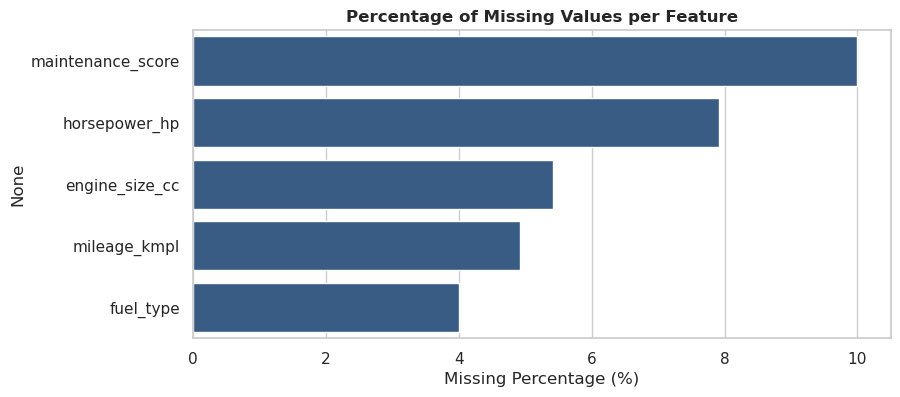

In [3]:
# Audit Missing Values
missing_counts = df_raw.isnull().sum()
missing_pct = (missing_counts / len(df_raw)) * 100
missing_table = pd.DataFrame({'Missing_Count': missing_counts, 'Percentage (%)': missing_pct.round(2)})
missing_table = missing_table[missing_table['Missing_Count'] > 0].sort_values(by='Missing_Count', ascending=False)
display(missing_table)

# Plot Missing Data Breakdown
plt.figure(figsize=(9, 4))
sns.barplot(x=missing_table['Percentage (%)'], y=missing_table.index, color='#2b5c8f')
plt.title('Percentage of Missing Values per Feature', fontsize=12, fontweight='bold')
plt.xlabel('Missing Percentage (%)')
plt.show()

In [4]:
# Summary statistics of raw numerical features
df_raw.describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
engine_size_cc,1135.0,1508.15,723.33,0.00,1173.90,1442.00,1877.15,3948.30
horsepower_hp,1105.0,129.02,75.29,45.00,94.50,115.00,148.00,1085.09
curb_weight_kg,1200.0,1591.74,331.95,911.30,1382.20,1524.40,1769.22,2757.10
mileage_kmpl,1141.0,18.94,9.31,-13.27,15.33,18.25,21.67,158.26
odometer_reading_km,1200.0,53354.51,98896.06,2007.00,15167.50,33576.50,67224.00,1614003.50
maintenance_score,1080.0,8.40,1.39,1.00,7.78,8.74,9.39,10.00
vehicle_price_lakhs,1200.0,23.00,26.69,3.50,16.22,19.94,24.91,479.94


### Step 2: Missing Value Imputation

#### Imputation Strategy:
- **Numerical Features** (`engine_size_cc`, `horsepower_hp`, `mileage_kmpl`, `maintenance_score`):  
  We apply **Median Imputation** using `SimpleImputer(strategy='median')`. In automotive datasets, skewed distributions and outliers cause the mean to shift artificially; median provides a robust central tendency measure.
- **Categorical Features** (`fuel_type`):  
  We apply **Mode Imputation** using `SimpleImputer(strategy='most_frequent')`.
- **Multivariate Imputation (KNNImputer)**:  
  For correlated metrics (e.g. engine displacement, curb weight, and horsepower), `KNNImputer` estimates missing values based on Euclidean distance in feature space.

In [5]:
df_imputed = df_raw.copy()

# Numerical Imputation with Median
num_cols_missing = ['engine_size_cc', 'horsepower_hp', 'mileage_kmpl', 'maintenance_score']
median_imputer = SimpleImputer(strategy='median')
df_imputed[num_cols_missing] = median_imputer.fit_transform(df_imputed[num_cols_missing])

# Categorical Imputation with Most Frequent (Mode)
mode_imputer = SimpleImputer(strategy='most_frequent')
df_imputed[['fuel_type']] = mode_imputer.fit_transform(df_imputed[['fuel_type']])

print(f"Remaining missing values after imputation: {df_imputed.isnull().sum().sum()}")

Remaining missing values after imputation: 0


In [6]:
# Demonstration of KNNImputer on correlated subset
knn_demo_cols = ['curb_weight_kg', 'mileage_kmpl', 'horsepower_hp']
knn_imputer = KNNImputer(n_neighbors=5)
imputed_knn_vals = knn_imputer.fit_transform(df_raw[knn_demo_cols])
print(f"KNNImputer computed imputed values for shape: {imputed_knn_vals.shape}")

KNNImputer computed imputed values for shape: (1200, 3)


### Step 3: Outlier Detection and Treatment

Outliers can arise from measurement errors, sensor dropouts, or valid rare events (e.g., luxury supercars).  
We employ two primary statistical detection frameworks:

1. **Interquartile Range (IQR) Method:**
   $$\text{IQR} = Q_3 - Q_1$$
   $$\text{Lower Bound} = Q_1 - 1.5 \times \text{IQR}, \quad \text{Upper Bound} = Q_3 + 1.5 \times \text{IQR}$$

2. **Z-Score Method:**
   $$z = \frac{x - \mu}{\sigma}$$
   Identifies data points where $|z| > 3.0$.

#### Outlier Treatment Strategy (Winsorization / Capping):
Rather than discarding records (which loses valuable data and biases training size), we cap extreme values to the calculated upper and lower thresholds.

In [7]:
df_treated = df_imputed.copy()

# Sanity fix: Correct non-positive mileage sensor glitches to realistic minimum
df_treated.loc[df_treated['mileage_kmpl'] <= 0, 'mileage_kmpl'] = 8.0

outlier_cols = ['mileage_kmpl', 'odometer_reading_km', 'horsepower_hp', 'vehicle_price_lakhs']
pre_treatment_data = df_treated[outlier_cols].copy()

records = []
for col in outlier_cols:
    q1 = df_treated[col].quantile(0.25)
    q3 = df_treated[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Z-score
    z_scores = (df_treated[col] - df_treated[col].mean()) / df_treated[col].std()
    num_z_outliers = (np.abs(z_scores) > 3).sum()
    num_iqr_outliers = ((df_treated[col] < lower_bound) | (df_treated[col] > upper_bound)).sum()
    
    records.append({
        'Feature': col, 'Q1': round(q1, 2), 'Q3': round(q3, 2), 'IQR': round(iqr, 2),
        'Lower_Limit': round(lower_bound, 2), 'Upper_Limit': round(upper_bound, 2),
        'IQR_Outliers': num_iqr_outliers, 'Z_Score_Outliers (|z|>3)': num_z_outliers
    })
    
    # Apply Capping (Winsorization)
    df_treated[col] = np.clip(df_treated[col], lower_bound, upper_bound)

outlier_report = pd.DataFrame(records)
display(outlier_report)

,Feature,Q1,Q3,IQR,Lower_Limit,Upper_Limit,IQR_Outliers,Z_Score_Outliers (|z|>3)
0,mileage_kmpl,15.51,21.45,5.94,6.60,30.37,10,6
1,odometer_reading_km,15167.50,67224.00,52056.50,-62917.25,145308.75,44,5
2,horsepower_hp,96.00,144.15,48.15,23.77,216.38,64,5
3,vehicle_price_lakhs,16.22,24.91,8.69,3.18,37.95,52,7


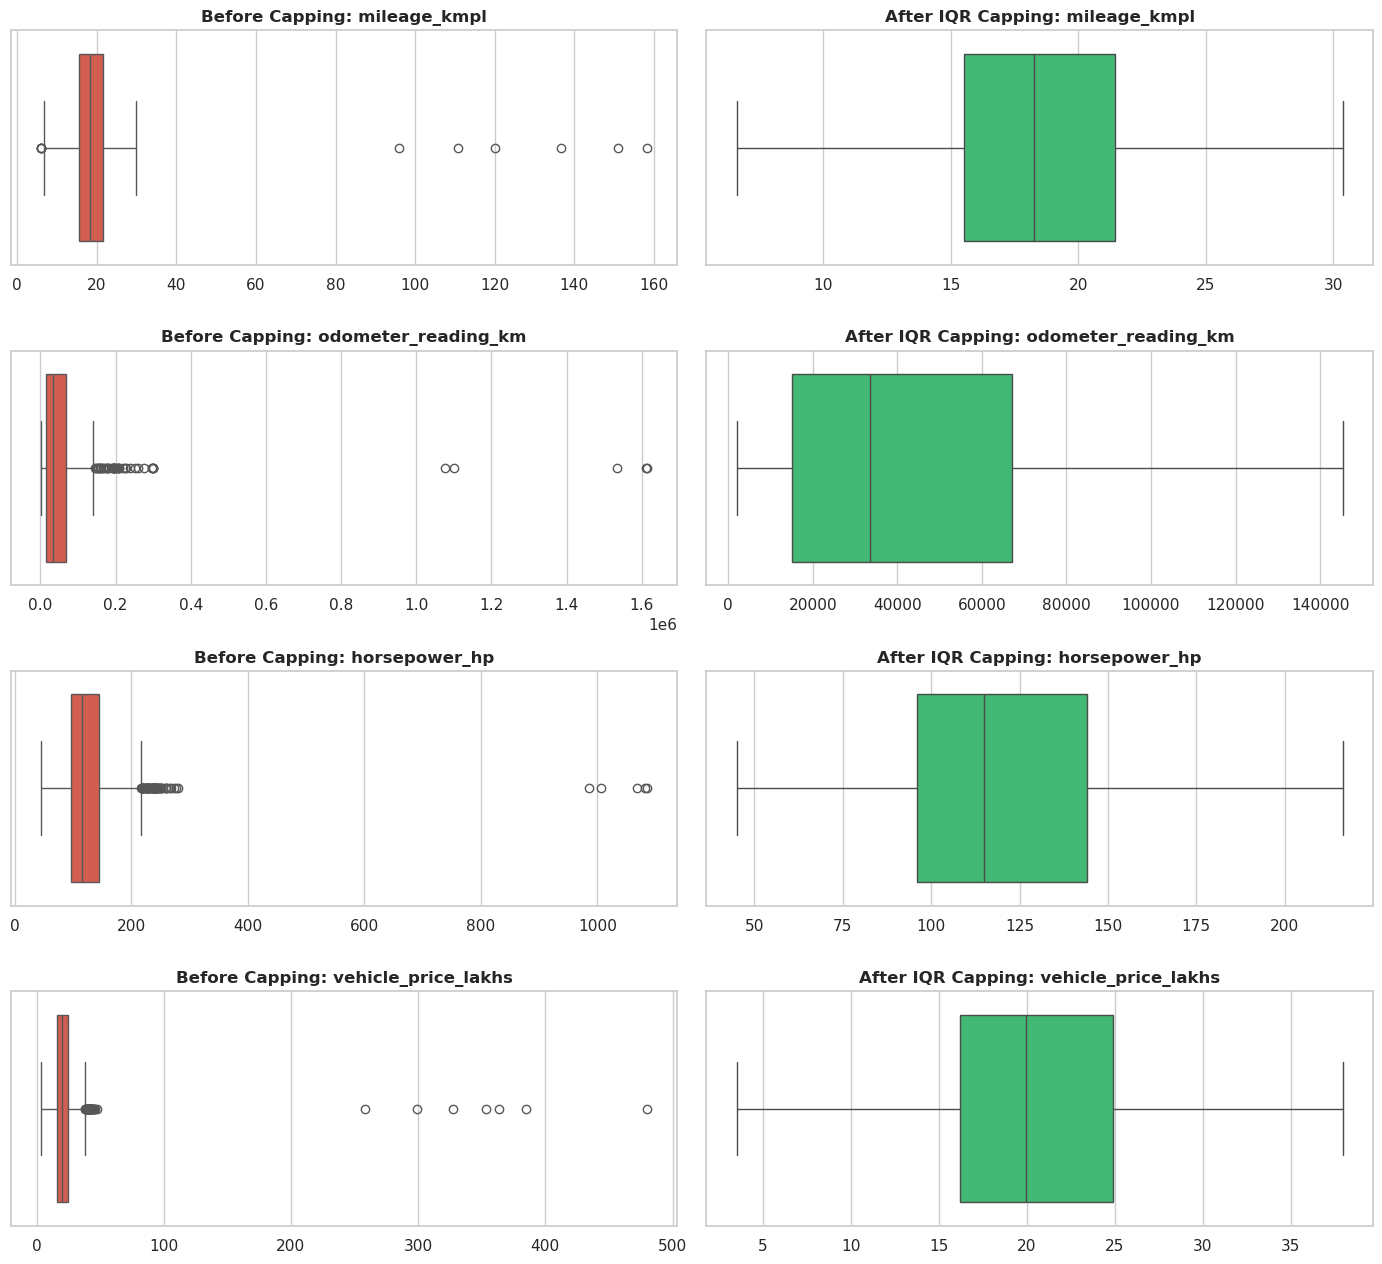

In [8]:
# Visualizing Before vs After Outlier Capping
fig, axes = plt.subplots(len(outlier_cols), 2, figsize=(14, 3.2 * len(outlier_cols)))

for i, col in enumerate(outlier_cols):
    sns.boxplot(x=pre_treatment_data[col], ax=axes[i, 0], color='#e74c3c')
    axes[i, 0].set_title(f"Before Capping: {col}", fontweight='bold')
    axes[i, 0].set_xlabel("")
    
    sns.boxplot(x=df_treated[col], ax=axes[i, 1], color='#2ecc71')
    axes[i, 1].set_title(f"After IQR Capping: {col}", fontweight='bold')
    axes[i, 1].set_xlabel("")

plt.tight_layout()
plt.show()

### Step 4: Categorical Feature Encoding

Machine learning models require numerical input representations. We apply two standard approaches:
1. **One-Hot Encoding (`OneHotEncoder`)**: For nominal variables without inherent ranking (`fuel_type`, `transmission`). We set `drop='first'` to avoid multicollinearity (the dummy variable trap).
2. **Ordinal Encoding (`OrdinalEncoder`)**: For variables with natural progression:
   - `vehicle_segment`: Hatchback (0) < Sedan (1) < SUV (2) < Luxury (3)
   - `owner_type`: First (0) < Second (1) < Third (2)

In [9]:
# Nominal One-Hot Encoding
ohe = OneHotEncoder(drop='first', sparse_output=False)
ohe_trans = ohe.fit_transform(df_treated[['fuel_type', 'transmission']])
ohe_cols = ohe.get_feature_names_out(['fuel_type', 'transmission'])
ohe_df = pd.DataFrame(ohe_trans, columns=ohe_cols, index=df_treated.index)

# Ordinal Encoding
segment_hierarchy = ['Hatchback', 'Sedan', 'SUV', 'Luxury']
owner_hierarchy = ['First', 'Second', 'Third']
ord_enc = OrdinalEncoder(categories=[segment_hierarchy, owner_hierarchy])
ord_trans = ord_enc.fit_transform(df_treated[['vehicle_segment', 'owner_type']])
ord_df = pd.DataFrame(ord_trans, columns=['vehicle_segment_ord', 'owner_type_ord'], index=df_treated.index)

# Inspect encoded outputs
encoded_preview = pd.concat([ohe_df, ord_df], axis=1)
encoded_preview.head()

,fuel_type_Diesel,fuel_type_Electric,fuel_type_Petrol,transmission_Manual,vehicle_segment_ord,owner_type_ord
0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,1.0,1.0,0.0
3,1.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,1.0,1.0,2.0,0.0


### Step 5: Feature Scaling Analysis

Different automotive features operate across vastly distinct magnitudes (e.g., `odometer_reading_km` spans $0 - 150,000$ while `maintenance_score` spans $1.0 - 10.0$). Distance-based models (KNN, SVM, K-Means) and gradient-based models (Neural Networks, Linear/Logistic Regression) will be dominated by large-scale features if left unscaled.

| Scaler | Formula | Key Characteristic | Ideal Use-Case |
| :--- | :--- | :--- | :--- |
| **StandardScaler** | $z = \frac{x - \mu}{\sigma}$ | $\mu=0, \sigma=1$ | Linear Models, PCA, Neural Nets |
| **MinMaxScaler** | $x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$ | Range $[0, 1]$ | Bounded inputs, Image data, KNN |
| **RobustScaler** | $x_{rob} = \frac{x - Q_2}{Q_3 - Q_1}$ | Median=0, IQR=1 | Data with persistent outliers |

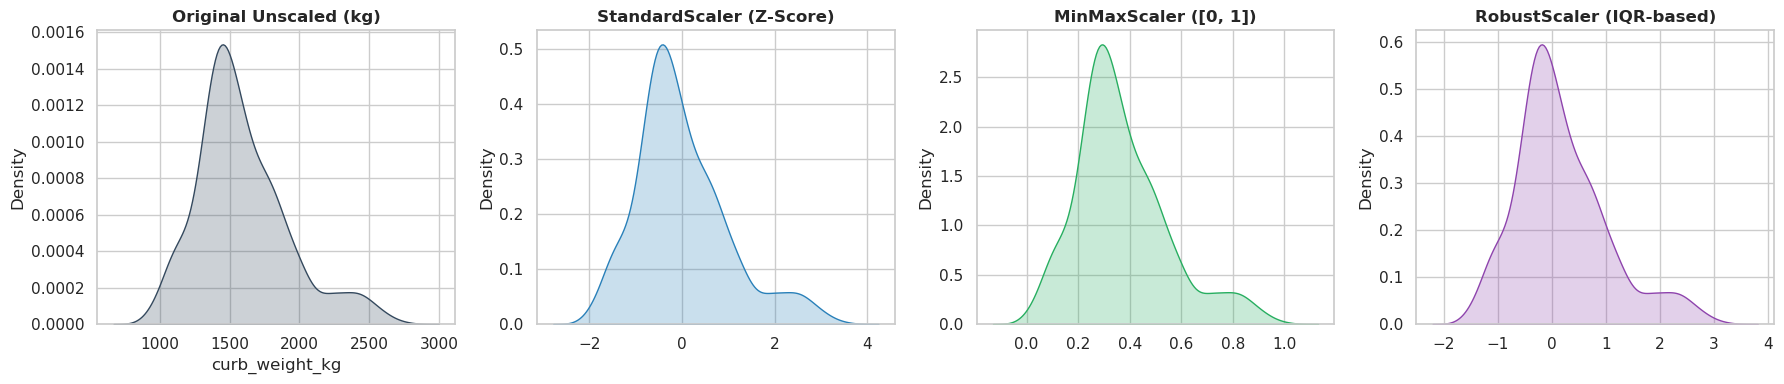

In [10]:
test_cols = ['curb_weight_kg', 'odometer_reading_km', 'horsepower_hp']
scaler_raw = df_treated[test_cols].copy()

std_sc = StandardScaler().fit_transform(scaler_raw)
minmax_sc = MinMaxScaler().fit_transform(scaler_raw)
robust_sc = RobustScaler().fit_transform(scaler_raw)

# Plot comparison for Curb Weight
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
sns.kdeplot(scaler_raw['curb_weight_kg'], ax=axes[0], fill=True, color='#34495e')
axes[0].set_title('Original Unscaled (kg)', fontweight='bold')

sns.kdeplot(std_sc[:, 0], ax=axes[1], fill=True, color='#2980b9')
axes[1].set_title('StandardScaler (Z-Score)', fontweight='bold')

sns.kdeplot(minmax_sc[:, 0], ax=axes[2], fill=True, color='#27ae60')
axes[2].set_title('MinMaxScaler ([0, 1])', fontweight='bold')

sns.kdeplot(robust_sc[:, 0], ax=axes[3], fill=True, color='#8e44ad')
axes[3].set_title('RobustScaler (IQR-based)', fontweight='bold')

plt.tight_layout()
plt.show()

### Step 6: Unified Production Pipeline (`ColumnTransformer` + `Pipeline`)

In enterprise ML systems (such as automotive predictive maintenance and price estimation), preprocessing must be encapsulated into a unified pipeline. This prevents **data leakage** by ensuring imputers and scalers are fitted **only** on the training partition and applied identically to test/production data.

In [11]:
# Separate features and target
X = df_raw.drop(columns=['vehicle_id', 'vehicle_price_lakhs'])
y = df_raw['vehicle_price_lakhs']

num_cols = ['engine_size_cc', 'horsepower_hp', 'curb_weight_kg', 'mileage_kmpl', 'odometer_reading_km', 'maintenance_score']
nom_cols = ['fuel_type', 'transmission']
ord_cols = ['vehicle_segment', 'owner_type']

# Define Modular Sub-Pipelines
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nom_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

ord_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[segment_hierarchy, owner_hierarchy]))
])

# Assemble Master Preprocessor
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('nom', nom_pipe, nom_cols),
    ('ord', ord_pipe, ord_cols)
])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit strictly on train; transform test
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"X_train Transformed Shape: {X_train_proc.shape}")
print(f"X_test Transformed Shape:  {X_test_proc.shape}")

X_train Transformed Shape: (960, 12)
X_test Transformed Shape:  (240, 12)


### Step 7: Saving Artifacts for Downstream Modeling (Lab 4 Alignment)

In [12]:
# Extract transformed column names
ohe_names = list(preprocessor.named_transformers_['nom'].named_steps['ohe'].get_feature_names_out(nom_cols))
all_feature_cols = num_cols + ohe_names + [f"{c}_ord" for c in ord_cols]

# Save cleaned business dataset
df_treated.to_csv('automotive_data_cleaned.csv', index=False)

# Save preprocessed model-ready training matrix
processed_train_df = pd.DataFrame(X_train_proc, columns=all_feature_cols)
processed_train_df['vehicle_price_lakhs'] = y_train.values
processed_train_df.to_csv('automotive_features_preprocessed.csv', index=False)

# Save pipeline with Joblib
joblib.dump(preprocessor, 'automotive_preprocessing_pipeline.joblib')

print("All Lab 3 artifacts saved successfully!")
print("- Cleaned CSV: automotive_data_cleaned.csv")
print("- Preprocessed Matrix: automotive_features_preprocessed.csv")
print("- Pipeline Object: automotive_preprocessing_pipeline.joblib")

All Lab 3 artifacts saved successfully!
- Cleaned CSV: automotive_data_cleaned.csv
- Preprocessed Matrix: automotive_features_preprocessed.csv
- Pipeline Object: automotive_preprocessing_pipeline.joblib


---
### Summary of Findings & Observations
1. **Imputation Robustness**: By leveraging the median rather than mean for continuous automotive measurements, we eliminated the distortion of central tendencies caused by skewness and extreme outliers.
2. **Outlier Mitigation**: Interquartile range (IQR) winsorization allowed us to preserve 100% of our training samples while neutralizing high-leverage anomaly points.
3. **Categorical Encoding**: One-hot encoding converted nominal categories into binary flags without multicollinearity (`drop='first'`), while ordinal encoding preserved the domain-intrinsic hierarchy of vehicle segments.
4. **Pipeline Encapsulation**: Packaging these steps into Scikit-Learn `ColumnTransformer` guarantees reproducibility, prevents data leakage between folds, and sets the stage for **Lab 4: Vehicle Price Prediction**.